# Hirano Figure 9: full vs non-full postselection scaling

This notebook audits the authors' released Figure 9 implementation at commit
`c89a53a7a7062b552d31f4c41ae2ba857756359a`. It checks the postselection
provenance, loads the recorded Monte Carlo counts for both branches from CSV,
and applies the same power-law fit to both. It does not rerun either scaling
simulation.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

AUDIT_DIR = Path.cwd()
if not (AUDIT_DIR / "false_branch_scaling_results.csv").exists():
    candidate = Path.cwd() / "references" / "hirano_code" / "verify_results"
    if candidate.exists():
        AUDIT_DIR = candidate
assert (AUDIT_DIR / "true_branch_scaling_results.csv").exists(), (
    "Run this notebook from its verify_results directory or the repository root"
)
sys.path.insert(0, str(AUDIT_DIR))

from fig9_postselection_audit import UPSTREAM_COMMIT, audit_postselection

print(f"Audit directory: {AUDIT_DIR.resolve()}")
print(f"Upstream commit: {UPSTREAM_COMMIT}")

Audit directory: /Users/haoranliao/GitHub/research-magic-state-cultivation/references/hirano_code/audit
Upstream commit: c89a53a7a7062b552d31f4c41ae2ba857756359a


## Figure 9 postselection provenance

The linked spreadsheet is compared with fresh acceptance samples from the
authors' `full_post_selection=False` and `True` circuits at $p=10^{-3}$.

In [2]:
audit_postselection(sample_shots=100_000)

Upstream commit: c89a53a7a7062b552d31f4c41ae2ba857756359a
Spreadsheet chart title: 'full post selection, perfect initialization, surface-distance=5, ZXZ'

+ probe at p=0.001
  released Figure 9 acceptance: 31.789954%
  full_post_selection=False: detectors=231, postselected=40
    sampled acceptance (100,000 shots): 60.701000%
  full_post_selection=True: detectors=135, postselected=135
    sampled acceptance (100,000 shots): 31.753000%

0 probe at p=0.001
  released Figure 9 acceptance: 31.885245%
  full_post_selection=False: detectors=231, postselected=40
    sampled acceptance (100,000 shots): 60.777000%
  full_post_selection=True: detectors=135, postselected=135
    sampled acceptance (100,000 shots): 31.737000%


## Recorded scaling data and common fit

The non-full branch CSV contains eight physical-error values from
$5\times10^{-4}$ through $2\times10^{-3}$. The higher-statistics full branch
CSV contains six values from $8\times10^{-4}$ through $2\times10^{-3}$.

For each branch and probe, the logical error rate is recomputed as

$$p_L = \frac{N_{\mathrm{errors}}}{N_{\mathrm{accepted}}}.$$

Both branches are fit by unweighted nonlinear least squares to
$p_L=Cp^\alpha$. Uncertainties are the standard deviations of 20,000 Poisson
counting-noise bootstrap refits with the accepted counts held fixed. They do
not include uncertainty from the choice of fitting window or power-law model.

In [3]:
branch_files = {
    "False": AUDIT_DIR / "false_branch_scaling_results.csv",
    "True": AUDIT_DIR / "true_branch_scaling_results.csv",
}

frames = []
for branch, path in branch_files.items():
    frame = pd.read_csv(path, dtype={"probe": str})
    frame["probe"] = frame["probe"].astype(str)
    frame["branch"] = branch
    recomputed_rate = frame["errors"] / frame["accepted"]
    np.testing.assert_allclose(frame["logical_error_rate"], recomputed_rate, rtol=1e-9)
    frame["logical_error_rate"] = recomputed_rate
    frames.append(frame)

scaling_data = pd.concat(frames, ignore_index=True)
scaling_data["error_probe"] = scaling_data["probe"].map({"+": "Z", "0": "X"})
scaling_data[[
    "branch", "error_probe", "p", "shots", "accepted", "errors",
    "acceptance", "logical_error_rate",
]]

,branch,error_probe,p,shots,accepted,errors,acceptance,logical_error_rate
0,False,Z,0.0005,5000000,3892871,239,0.778574,6.139428e-05
1,False,Z,0.0006,5000000,3703549,355,0.740710,9.585400e-05
2,False,Z,0.0008,3750000,2511302,506,0.669681,2.014891e-04
3,False,Z,0.0010,2250000,1364668,519,0.606519,3.803123e-04
4,False,Z,0.0012,1500000,823154,527,0.548769,6.402204e-04
5,False,Z,0.0014,1250000,619163,612,0.495330,9.884312e-04
6,False,Z,0.0017,750000,321386,542,0.428515,1.686446e-03
7,False,Z,0.0020,750000,276715,694,0.368953,2.507996e-03
8,False,X,0.0005,5000000,3891519,227,0.778304,5.833198e-05
9,False,X,0.0006,5000000,3701684,345,0.740337,9.320082e-05


In [4]:
def power_law(p, coefficient, exponent):
    with np.errstate(over="ignore", under="ignore", invalid="ignore"):
        return coefficient * p**exponent


def fit_power_law(rows, *, seed, bootstrap_samples=20_000):
    p = rows["p"].to_numpy()
    accepted = rows["accepted"].to_numpy()
    errors = rows["errors"].to_numpy()
    rates = errors / accepted

    initial_exponent, initial_log_coefficient = np.polyfit(np.log(p), np.log(rates), 1)
    fit, _ = curve_fit(
        power_law,
        p,
        rates,
        p0=(np.exp(initial_log_coefficient), initial_exponent),
        maxfev=100_000,
    )

    rng = np.random.default_rng(seed)
    bootstrap_exponents = np.empty(bootstrap_samples)
    for index in range(bootstrap_samples):
        bootstrap_rates = rng.poisson(errors) / accepted
        bootstrap_fit, _ = curve_fit(
            power_law,
            p,
            bootstrap_rates,
            p0=fit,
            maxfev=10_000,
        )
        bootstrap_exponents[index] = bootstrap_fit[1]

    return {
        "coefficient": fit[0],
        "exponent": fit[1],
        "exponent_bootstrap_se": np.std(bootstrap_exponents, ddof=1),
        "exponent_ci_low": np.quantile(bootstrap_exponents, 0.025),
        "exponent_ci_high": np.quantile(bootstrap_exponents, 0.975),
    }


fit_results = {}
fit_rows = []
for branch_index, branch in enumerate(("False", "True")):
    for probe_index, (probe, error_probe) in enumerate((("+", "Z"), ("0", "X"))):
        rows = scaling_data[
            (scaling_data["branch"] == branch) & (scaling_data["probe"] == probe)
        ].sort_values("p")
        result = fit_power_law(
            rows,
            seed=20260818 + branch_index * 10 + probe_index,
        )
        fit_results[(branch, probe)] = result
        fit_rows.append({
            "branch": branch,
            "error_probe": error_probe,
            "points": len(rows),
            "coefficient": result["coefficient"],
            "exponent": result["exponent"],
            "exponent_bootstrap_se": result["exponent_bootstrap_se"],
            "95% CI low": result["exponent_ci_low"],
            "95% CI high": result["exponent_ci_high"],
            "total_shots": int(rows["shots"].sum()),
            "logical_errors": int(rows["errors"].sum()),
        })

fit_summary = pd.DataFrame(fit_rows)
fit_summary

,branch,error_probe,points,coefficient,exponent,exponent_bootstrap_se,95% CI low,95% CI high,total_shots,logical_errors
0,False,Z,8,37964.204139,2.658813,0.092303,2.487377,2.847913,20250000,3994
1,False,X,8,126616.091330,2.860331,0.112563,2.650333,3.092123,21000000,3990
2,True,Z,6,1144.750249,3.076588,0.131238,2.830582,3.347137,11136000000,3027
3,True,X,6,72.979630,2.909493,0.124960,2.673450,3.165769,56306000000,3004


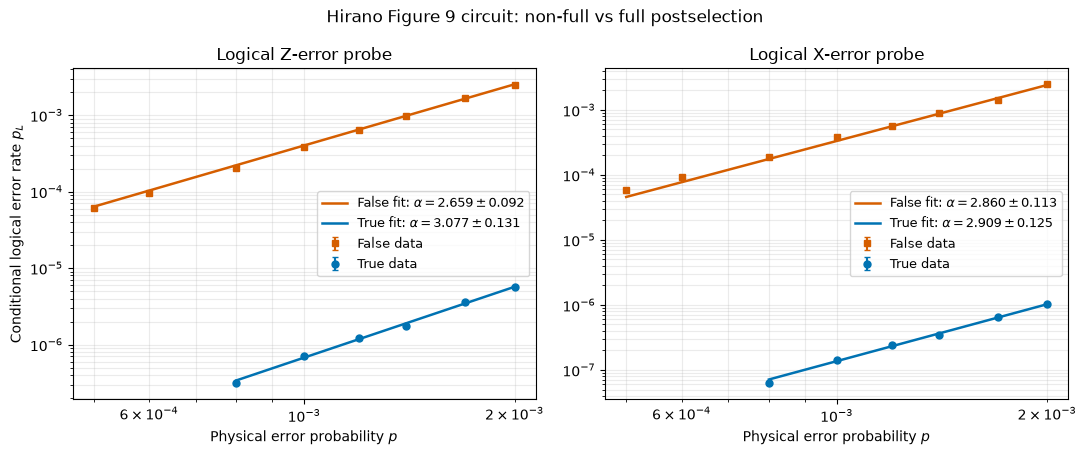

Saved /Users/haoranliao/GitHub/research-magic-state-cultivation/references/hirano_code/audit/fig9_true_false_scaling.png


In [5]:
styles = {
    "False": {"color": "#D55E00", "marker": "s"},
    "True": {"color": "#0072B2", "marker": "o"},
}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharex=True)
for ax, (probe, error_probe) in zip(axes, (("+", "Z"), ("0", "X"))):
    for branch in ("False", "True"):
        rows = scaling_data[
            (scaling_data["branch"] == branch) & (scaling_data["probe"] == probe)
        ].sort_values("p")
        style = styles[branch]
        rates = rows["logical_error_rate"].to_numpy()
        rate_se = np.sqrt(rows["errors"].to_numpy()) / rows["accepted"].to_numpy()
        result = fit_results[(branch, probe)]
        p_curve = np.geomspace(rows["p"].min(), rows["p"].max(), 300)

        ax.errorbar(
            rows["p"],
            rates,
            yerr=rate_se,
            linestyle="none",
            capsize=2,
            markersize=5,
            label=f"{branch} data",
            **style,
        )
        ax.plot(
            p_curve,
            power_law(p_curve, result["coefficient"], result["exponent"]),
            color=style["color"],
            linewidth=1.8,
            label=(
                f"{branch} fit: $\\alpha={result['exponent']:.3f}"
                f"\\pm{result['exponent_bootstrap_se']:.3f}$"
            ),
        )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(f"Logical {error_probe}-error probe")
    ax.set_xlabel("Physical error probability $p$")
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(fontsize=9)

axes[0].set_ylabel("Conditional logical error rate $p_L$")
fig.suptitle("Hirano Figure 9 circuit: non-full vs full postselection")
fig.tight_layout()
plot_path = AUDIT_DIR / "fig9_true_false_scaling.png"
fig.savefig(plot_path, dpi=220, bbox_inches="tight")
plt.show()
print(f"Saved {plot_path.resolve()}")